# Model C: EfficientNetB0 with low-light augmentation

This experiment tests a targeted response to illumination shift. Model C uses the same data split, frozen EfficientNetB0 backbone, classification head, optimizer, callbacks, and clean test set as Models A and B. The only change is low-light augmentation applied to training images.

The corruption is calculated after converting pixels from 0–255 to 0–1. This matters because gamma correction and Gaussian-noise scales are only meaningful in a known range. No rotations, flips, translations, or zoom are used here; those belong to Model B and will be combined with this pipeline in Model D.

In [1]:
from pathlib import Path
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

Python: 3.13.15
TensorFlow: 2.20.0
GPU available: True


## Experiment settings

For each selected training image, the transform uses $y = e\,x^{\gamma} + n$, where $x$ is in the range 0–1, $e$ is an exposure multiplier, and $n$ is Gaussian sensor noise. The parameters are sampled independently for each image.

I keep 25% of training images clean. This prevents Model C from seeing only dark images and makes the augmentation a mixture of source and simulated target conditions. The ranges below are fixed before inspecting any low-light test result.

In [2]:
CLASS_NAMES = ['angry', 'happy', 'sad']
DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/Emotions Dataset')
LOCAL_DATASET_DIR = Path('/content/emotions_dataset')
PROJECT_OUTPUT_DIR = Path('/content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs')
OUTPUT_DIR = PROJECT_OUTPUT_DIR / 'model_c'
MODEL_A_RESULTS_PATH = PROJECT_OUTPUT_DIR / 'model_a' / 'results_summary.json'
MODEL_B_RESULTS_PATH = PROJECT_OUTPUT_DIR / 'model_b' / 'results_summary.json'

CONFIG = {
    'image_size': (224, 224),
    'batch_size': 32,
    'validation_split': 0.20,
    'epochs': 30,
    'learning_rate': 1e-3,
    'dropout_rate': 0.30,
    'dense_units': 256,
    'low_light_probability': 0.75,
    'gamma_range': (1.10, 1.80),
    'exposure_range': (0.60, 0.95),
    'noise_stddev_range': (0.00, 0.03),
}

CONFIG

{'image_size': (224, 224),
 'batch_size': 32,
 'validation_split': 0.2,
 'epochs': 30,
 'learning_rate': 0.001,
 'dropout_rate': 0.3,
 'dense_units': 256,
 'low_light_probability': 0.75,
 'gamma_range': (1.1, 1.8),
 'exposure_range': (0.6, 0.95),
 'noise_stddev_range': (0.0, 0.03)}

## Prepare the dataset

The original `train` folder is split into training and validation subsets exactly as before. The original `test` folder remains untouched until final evaluation. I also load the saved summaries from Models A and B so the clean-test comparison uses their recorded results rather than re-evaluating or copying numbers by hand.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

required_directories = [
    DRIVE_DATASET_DIR / split / class_name
    for split in ['train', 'test']
    for class_name in CLASS_NAMES
]
missing_directories = [path for path in required_directories if not path.is_dir()]

if missing_directories:
    missing_text = '\n'.join(str(path) for path in missing_directories)
    raise FileNotFoundError(f"The following dataset folders were not found:\n{missing_text}")

if not LOCAL_DATASET_DIR.exists():
    print('Copying the dataset from Drive to the Colab runtime...')
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print('Copy complete.')
else:
    print('Using the dataset already copied to the Colab runtime.')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR = LOCAL_DATASET_DIR / 'train'
TEST_DIR = LOCAL_DATASET_DIR / 'test'

for result_path, model_name in [
    (MODEL_A_RESULTS_PATH, 'Model A'),
    (MODEL_B_RESULTS_PATH, 'Model B'),
]:
    if not result_path.is_file():
        raise FileNotFoundError(
            f"{model_name} results were not found at {result_path}. "
            f"Run the {model_name} notebook first."
        )

with open(MODEL_A_RESULTS_PATH) as file:
    model_a_results = json.load(file)
with open(MODEL_B_RESULTS_PATH) as file:
    model_b_results = json.load(file)

print(f"Model A clean-test accuracy: {model_a_results['test_accuracy']:.4f}")
print(f"Model B clean-test accuracy: {model_b_results['test_accuracy']:.4f}")

Mounted at /content/drive
Copying the dataset from Drive to the Colab runtime...
Copy complete.
Model A clean-test accuracy: 0.8169
Model B clean-test accuracy: 0.7805


In [4]:
common_dataset_options = {
    'image_size': CONFIG['image_size'],
    'batch_size': CONFIG['batch_size'],
    'label_mode': 'categorical',
    'class_names': CLASS_NAMES,
}

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=CONFIG['validation_split'],
    subset='training',
    seed=SEED,
    shuffle=True,
    **common_dataset_options,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=CONFIG['validation_split'],
    subset='validation',
    seed=SEED,
    shuffle=True,
    **common_dataset_options,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    **common_dataset_options,
)

test_file_paths = list(test_dataset.file_paths)
AUTOTUNE = tf.data.AUTOTUNE

Found 6799 files belonging to 3 classes.
Using 5440 files for training.
Found 6799 files belonging to 3 classes.
Using 1359 files for validation.
Found 2278 files belonging to 3 classes.


## Define and inspect the low-light augmentation

EfficientNetB0 expects images in the 0–255 range because its Keras implementation contains the rescaling operation internally. The augmentation therefore normalizes temporarily, applies the corruption, clips valid normalized pixels, and converts back to 0–255 before the image enters the model.

Only `low_light_train_dataset` is augmented. Validation and test datasets remain clean.

In [5]:
def apply_random_low_light(images):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.clip_by_value(images, 0.0, 1.0)

    parameter_shape = [tf.shape(images)[0], 1, 1, 1]
    apply_mask = tf.random.uniform(
        parameter_shape, seed=SEED
    ) < CONFIG['low_light_probability']

    gamma = tf.random.uniform(
        parameter_shape,
        minval=CONFIG['gamma_range'][0],
        maxval=CONFIG['gamma_range'][1],
        seed=SEED + 1,
    )
    exposure = tf.random.uniform(
        parameter_shape,
        minval=CONFIG['exposure_range'][0],
        maxval=CONFIG['exposure_range'][1],
        seed=SEED + 2,
    )
    noise_stddev = tf.random.uniform(
        parameter_shape,
        minval=CONFIG['noise_stddev_range'][0],
        maxval=CONFIG['noise_stddev_range'][1],
        seed=SEED + 3,
    )

    darkened_images = exposure * tf.pow(images, gamma)
    noise = tf.random.normal(tf.shape(images), seed=SEED + 4) * noise_stddev
    corrupted_images = tf.clip_by_value(darkened_images + noise, 0.0, 1.0)
    output_images = tf.where(apply_mask, corrupted_images, images)

    return output_images * 255.0


def augment_training_batch(images, labels):
    return apply_random_low_light(images), labels


low_light_train_dataset = train_dataset.map(
    augment_training_batch,
    # The random operations are stateful, so a single mapping worker keeps
    # their seeded sequence reproducible across runs.
    num_parallel_calls=1,
    deterministic=True,
).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

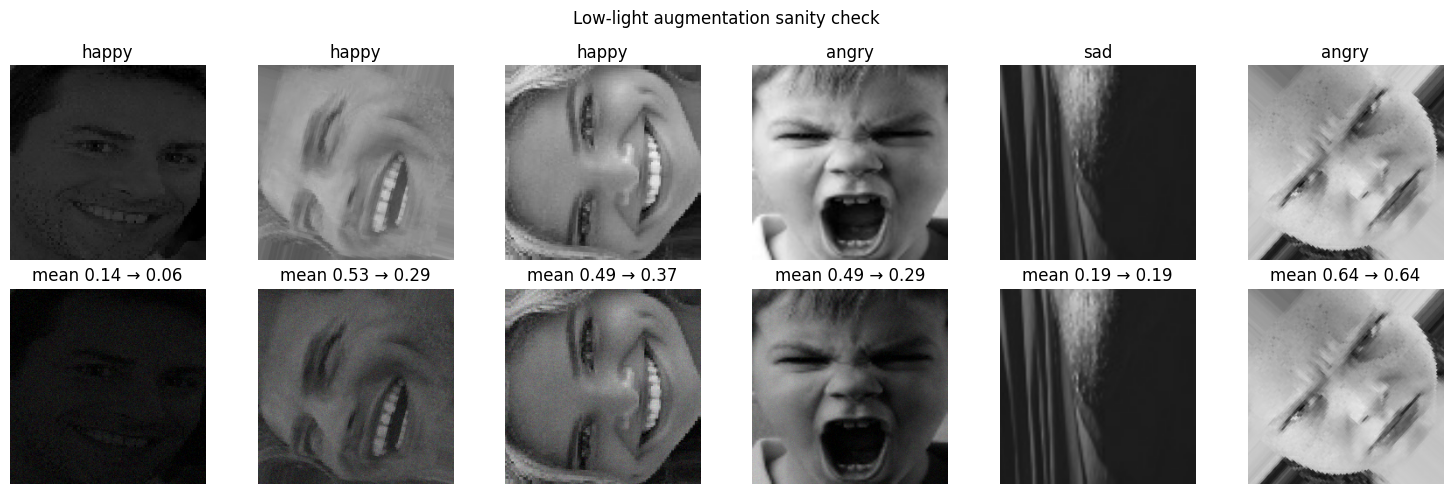

Original pixel range: 0.0 to 255.0
Augmented pixel range: 0.0 to 232.0


In [6]:
sample_images, sample_labels = next(iter(train_dataset))
sample_augmented = apply_random_low_light(sample_images[:6])

original_means = tf.reduce_mean(sample_images[:6], axis=(1, 2, 3)) / 255.0
augmented_means = tf.reduce_mean(sample_augmented, axis=(1, 2, 3)) / 255.0

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for index in range(6):
    label_index = int(tf.argmax(sample_labels[index]))

    axes[0, index].imshow(sample_images[index].numpy().astype('uint8'))
    axes[0, index].set_title(CLASS_NAMES[label_index])
    axes[0, index].axis('off')

    clipped_image = tf.clip_by_value(sample_augmented[index], 0, 255)
    axes[1, index].imshow(clipped_image.numpy().astype('uint8'))
    axes[1, index].set_title(
        f"mean {float(original_means[index]):.2f} → {float(augmented_means[index]):.2f}"
    )
    axes[1, index].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Training input', fontsize=12)
fig.suptitle('Low-light augmentation sanity check')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'augmentation_preview.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Original pixel range: {sample_images.numpy().min():.1f} to {sample_images.numpy().max():.1f}")
print(f"Augmented pixel range: {sample_augmented.numpy().min():.1f} to {sample_augmented.numpy().max():.1f}")

## Define Model C

The network is deliberately identical to Model A. The low-light transform lives in the training data pipeline rather than the saved model, so the resulting checkpoint accepts ordinary 0–255 images and can later be evaluated under any fixed lighting condition.

In [7]:
tf.keras.utils.set_random_seed(SEED)

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=CONFIG['image_size'] + (3,),
)
base_model.trainable = False

inputs = tf.keras.Input(shape=CONFIG['image_size'] + (3,), name='image')
features = base_model(inputs, training=False)
features = layers.GlobalAveragePooling2D(name='global_average_pooling')(features)
features = layers.Dropout(CONFIG['dropout_rate'], name='dropout')(features)
features = layers.Dense(CONFIG['dense_units'], activation='relu', name='classifier_dense')(features)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax', name='emotion')(features)

model = tf.keras.Model(inputs, outputs, name='model_c_low_light_augmentation')
model.summary()

trainable_parameters = sum(np.prod(variable.shape) for variable in model.trainable_weights)
print(f"Trainable parameters: {trainable_parameters:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "model_c_low_light_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Trainable parameters: 328,707


## Train with the same selection protocol

The callback settings and validation criterion match Models A and B. Checkpoint selection still uses clean validation loss, so the comparison is not helped by a different stopping rule and the test set remains outside training.

In [8]:
checkpoint_path = OUTPUT_DIR / 'model_c_low_light_augmentation.keras'
training_log_path = OUTPUT_DIR / 'training_log.csv'

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
    ],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(training_log_path)),
]

In [9]:
history = model.fit(
    low_light_train_dataset,
    validation_data=validation_dataset,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/30

Epoch 1: val_loss improved from None to 0.70644, saving model to /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/model_c/model_c_low_light_augmentation.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/model_c/model_c_low_light_augmentation.keras
170/170 - 76s - 445ms/step - accuracy: 0.6191 - loss: 0.8474 - top_2_accuracy: 0.8605 - val_accuracy: 0.6902 - val_loss: 0.7064 - val_top_2_accuracy: 0.9051 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss improved from 0.70644 to 0.62306, saving model to /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/model_c/model_c_low_light_augmentation.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/model_c/model_c_low_light_augmentation.keras
170/170 - 58s - 342ms/step - accuracy: 0.6910 - loss: 0.7026 - top_2_accuracy: 0.9026 - val_accuracy: 0.7292 - val_loss: 0.6231 - val_top_2_accuracy: 0.

## Evaluate the saved checkpoint on clean test images

This evaluation measures the clean-accuracy cost, if any, of training with illumination corruption. It does **not** yet measure low-light robustness. That comparison will use the same fixed mild, moderate, and severe test corruptions for every model after Models C and D are trained.

In [10]:
best_model = tf.keras.models.load_model(str(checkpoint_path))
test_metrics = best_model.evaluate(test_dataset, return_dict=True, verbose=1)

print('\nClean test metrics')
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8161 - loss: 0.4786 - top_2_accuracy: 0.9442

Clean test metrics
accuracy: 0.8161
loss: 0.4786
top_2_accuracy: 0.9442


In [11]:
probabilities = best_model.predict(test_dataset, verbose=1)
predicted_labels = np.argmax(probabilities, axis=1)
true_labels = np.concatenate([
    np.argmax(batch_labels.numpy(), axis=1)
    for _, batch_labels in test_dataset
])

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True,
)

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

predictions = pd.DataFrame({
    'file': test_file_paths,
    'true_label': [CLASS_NAMES[index] for index in true_labels],
    'predicted_label': [CLASS_NAMES[index] for index in predicted_labels],
})
for class_index, class_name in enumerate(CLASS_NAMES):
    predictions[f'prob_{class_name}'] = probabilities[:, class_index]

predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step
              precision    recall  f1-score   support

       angry     0.8313    0.6602    0.7359       515
       happy     0.8415    0.8917    0.8658      1006
         sad     0.7746    0.8217    0.7974       757

    accuracy                         0.8161      2278
   macro avg     0.8158    0.7912    0.7997      2278
weighted avg     0.8169    0.8161    0.8137      2278



## Inspect the training behavior and class-level errors

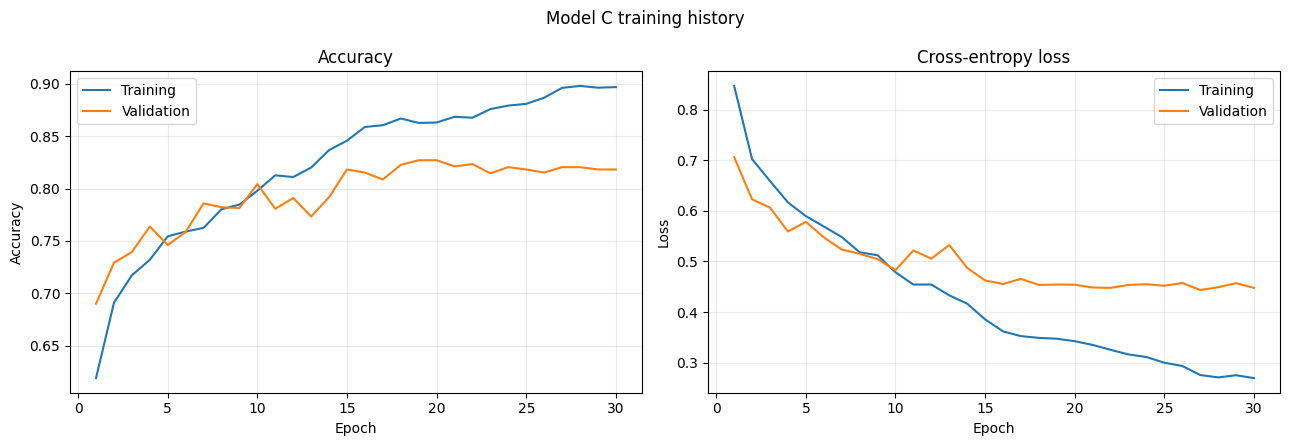

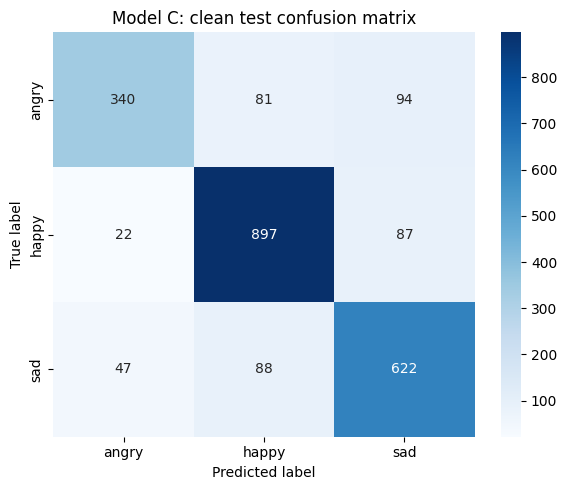

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_ran = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'], label='Training')
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Validation')
axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs_ran, history.history['loss'], label='Training')
axes[1].plot(epochs_ran, history.history['val_loss'], label='Validation')
axes[1].set(title='Cross-entropy loss', xlabel='Epoch', ylabel='Loss')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle('Model C training history')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Model C: clean test confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## Compare clean-test performance

A lower clean score would not automatically make Model C unsuccessful: targeted robustness can involve a clean-versus-corrupted performance trade-off. The fixed low-light evaluation will determine whether any trade-off is worthwhile.

,Model,Accuracy,Macro-F1
0,Model A: no augmentation,0.8169,0.8028
1,Model B: geometric,0.7805,0.7550
2,Model C: low-light,0.8161,0.7997


Accuracy change from Model A: -0.0009
Macro-F1 change from Model A: -0.0031


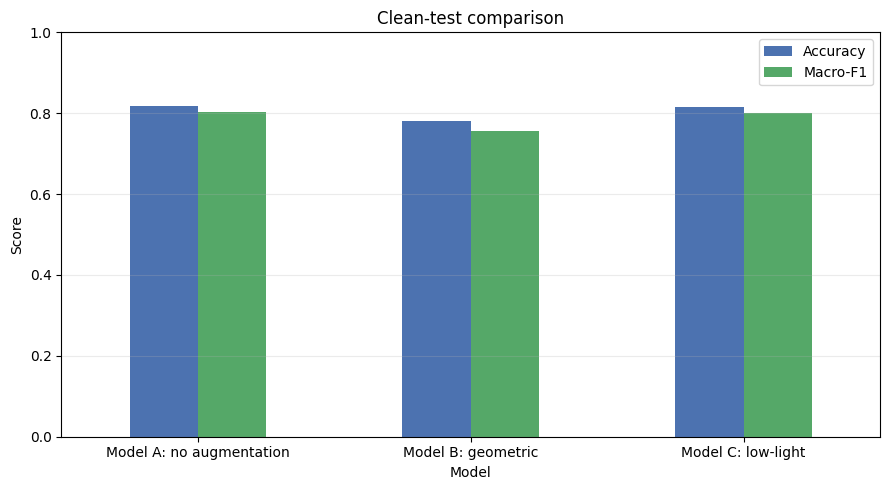

In [13]:
model_c_accuracy = float(test_metrics['accuracy'])
model_c_macro_f1 = float(report['macro avg']['f1-score'])
accuracy_change_from_a = model_c_accuracy - float(model_a_results['test_accuracy'])
macro_f1_change_from_a = model_c_macro_f1 - float(model_a_results['test_macro_f1'])

comparison = pd.DataFrame({
    'Model': [
        'Model A: no augmentation',
        'Model B: geometric',
        'Model C: low-light',
    ],
    'Accuracy': [
        model_a_results['test_accuracy'],
        model_b_results['test_accuracy'],
        model_c_accuracy,
    ],
    'Macro-F1': [
        model_a_results['test_macro_f1'],
        model_b_results['test_macro_f1'],
        model_c_macro_f1,
    ],
})
display(comparison.style.format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'}))

print(f"Accuracy change from Model A: {accuracy_change_from_a:+.4f}")
print(f"Macro-F1 change from Model A: {macro_f1_change_from_a:+.4f}")

comparison_plot = comparison.set_index('Model').plot.bar(
    figsize=(9, 5),
    ylim=(0, 1),
    rot=0,
    color=['#4C72B0', '#55A868'],
)
comparison_plot.set_ylabel('Score')
comparison_plot.set_title('Clean-test comparison')
comparison_plot.grid(axis='y', alpha=0.25)
comparison_plot.figure.tight_layout()
comparison_plot.figure.savefig(
    OUTPUT_DIR / 'comparison_with_models_a_b.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

In [14]:
history_to_save = {
    name: [float(value) for value in values]
    for name, values in history.history.items()
}

with open(OUTPUT_DIR / 'training_history.json', 'w') as file:
    json.dump(history_to_save, file, indent=2)

best_epoch = int(np.argmin(history.history['val_loss']) + 1)
results_summary = {
    'experiment': 'Model C - randomized low-light augmentation',
    'seed': SEED,
    'tensorflow_version': tf.__version__,
    'image_size': list(CONFIG['image_size']),
    'batch_size': CONFIG['batch_size'],
    'validation_split': CONFIG['validation_split'],
    'augmentation': {
        'formula': 'clip(exposure * (image / 255) ** gamma + noise, 0, 1) * 255',
        'application_probability': CONFIG['low_light_probability'],
        'gamma_range': list(CONFIG['gamma_range']),
        'exposure_range': list(CONFIG['exposure_range']),
        'noise_stddev_range_normalized': list(CONFIG['noise_stddev_range']),
        'geometric_transforms': False,
        'validation_and_test_augmented': False,
    },
    'epochs_completed': len(history.history['loss']),
    'best_epoch_by_validation_loss': best_epoch,
    'best_validation_loss': float(min(history.history['val_loss'])),
    'best_validation_accuracy': float(max(history.history['val_accuracy'])),
    'test_condition': 'clean',
    'test_loss': float(test_metrics['loss']),
    'test_accuracy': model_c_accuracy,
    'test_top_2_accuracy': float(test_metrics['top_2_accuracy']),
    'test_macro_f1': model_c_macro_f1,
    'test_weighted_f1': float(report['weighted avg']['f1-score']),
    'model_a_test_accuracy': float(model_a_results['test_accuracy']),
    'model_a_test_macro_f1': float(model_a_results['test_macro_f1']),
    'model_b_test_accuracy': float(model_b_results['test_accuracy']),
    'model_b_test_macro_f1': float(model_b_results['test_macro_f1']),
    'accuracy_change_from_model_a': accuracy_change_from_a,
    'macro_f1_change_from_model_a': macro_f1_change_from_a,
    'classification_report': report,
}

with open(OUTPUT_DIR / 'results_summary.json', 'w') as file:
    json.dump(results_summary, file, indent=2)

print(json.dumps({
    'best_epoch': results_summary['best_epoch_by_validation_loss'],
    'test_condition': results_summary['test_condition'],
    'test_accuracy': results_summary['test_accuracy'],
    'test_macro_f1': results_summary['test_macro_f1'],
    'accuracy_change_from_model_a': results_summary['accuracy_change_from_model_a'],
    'macro_f1_change_from_model_a': results_summary['macro_f1_change_from_model_a'],
}, indent=2))
print(f"\nSaved all Model C outputs to: {OUTPUT_DIR}")

{
  "best_epoch": 27,
  "test_condition": "clean",
  "test_accuracy": 0.8160667419433594,
  "test_macro_f1": 0.7997322497322497,
  "accuracy_change_from_model_a": -0.0008779168128967285,
  "macro_f1_change_from_model_a": -0.0031139168495964986
}

Saved all Model C outputs to: /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/model_c
